In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# set style for better graphs
sns.set(style="whitegrid")

In [ ]:
# sns.load_dataset # This line is not needed for loading local CSVs
matches = pd.read_csv("/content/matches.csv")
deliveries = pd.read_csv("/content/deliveries.csv")

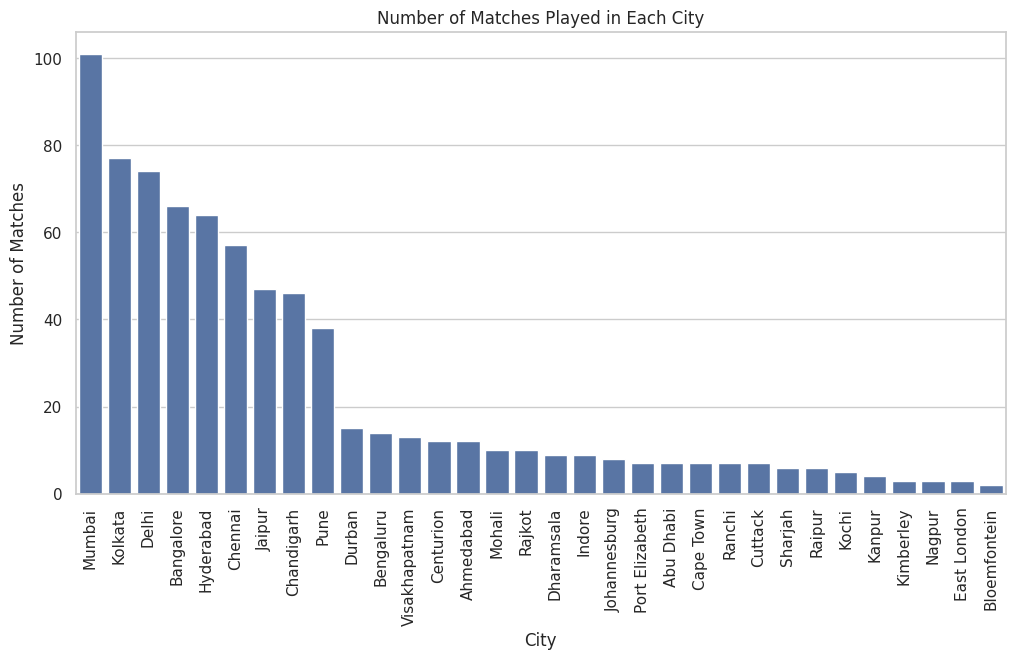

In [ ]:
#Jagriti Tiwari

plt.figure(figsize=(12, 6))
sns.countplot(x='city', data=matches, order = matches['city'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Number of Matches Played in Each City')
plt.xlabel('City')
plt.ylabel('Number of Matches')
plt.show()

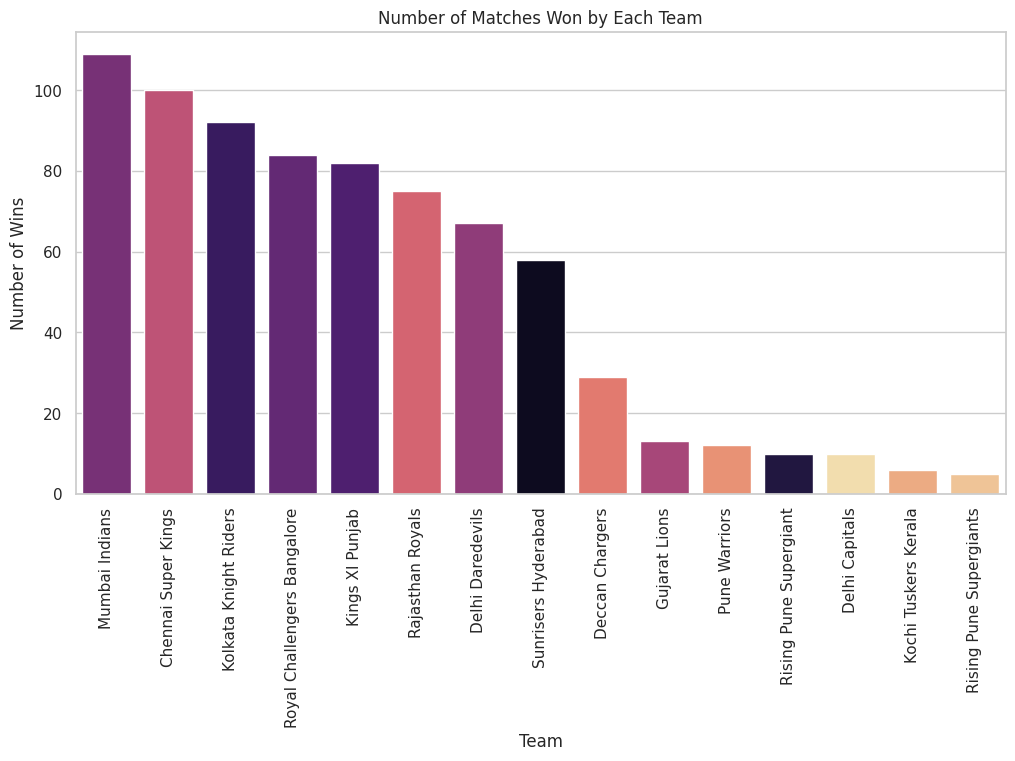

In [ ]:
#Jagriti Tiwari

plt.figure(figsize=(12, 6))
sns.countplot(x='winner', data=matches, order = matches['winner'].value_counts().index, hue='winner', palette='magma', legend=False)
plt.xticks(rotation=90)
plt.title('Number of Matches Won by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.show()

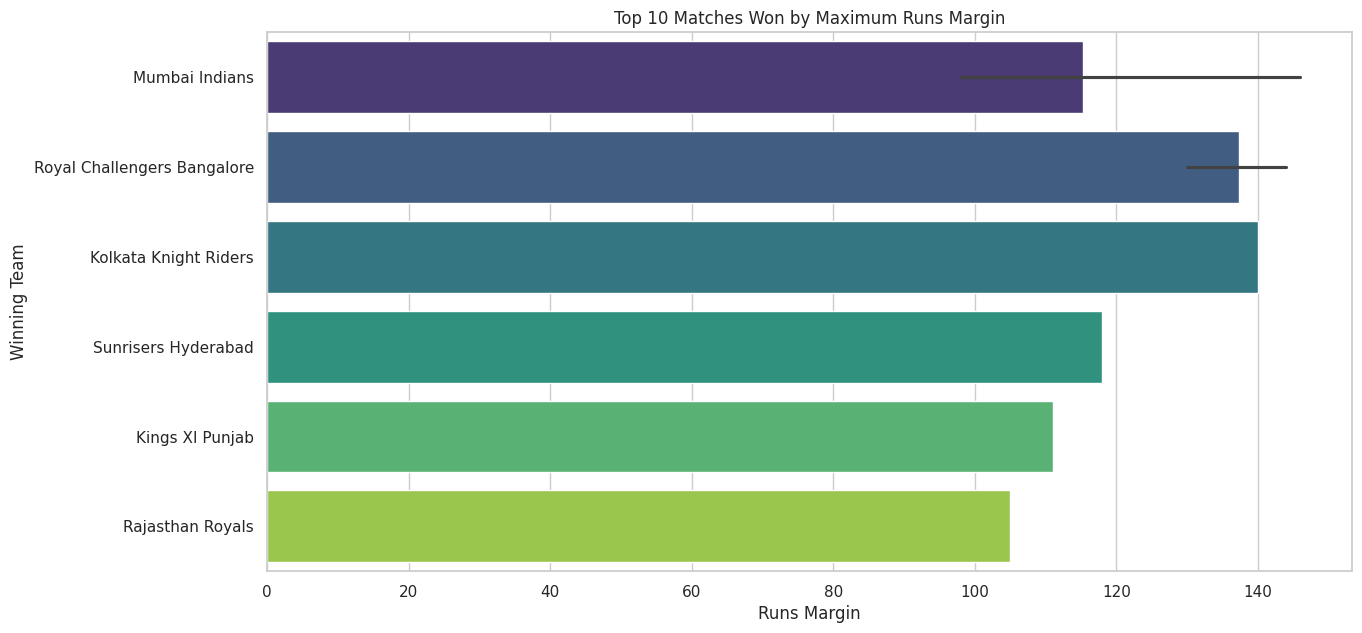

In [ ]:
#Jagriti Tiwari
# Filter for matches won by runs (not wickets or tie)

matches_by_runs = matches[matches['win_by_runs'] > 0]

# Sort by win_by_runs in descending order and get the top 10
top_10_margin_wins = matches_by_runs.sort_values(by='win_by_runs', ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x='win_by_runs', y='winner', data=top_10_margin_wins, hue='winner', palette='viridis', legend=False)
plt.title('Top 10 Matches Won by Maximum Runs Margin')
plt.xlabel('Runs Margin')
plt.ylabel('Winning Team')
plt.show()

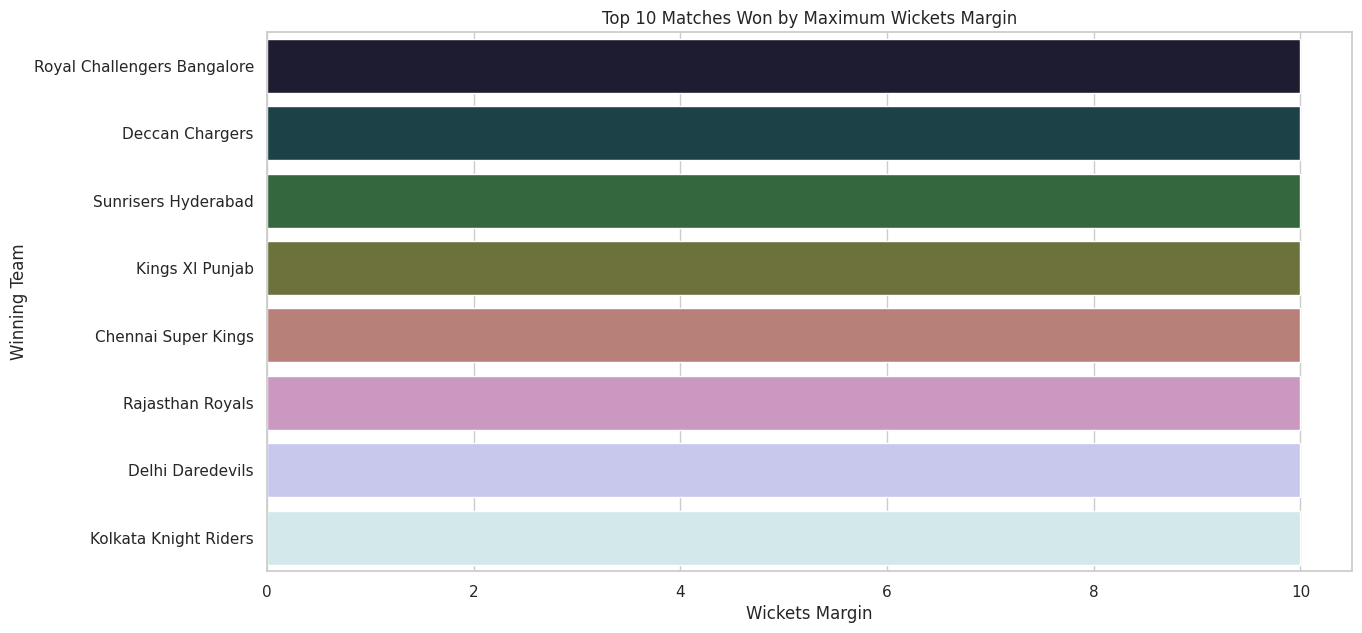

In [ ]:
#Jagriti Tiwari
# Filter for matches won by wickets (not runs or tie)

matches_by_wickets = matches[matches['win_by_wickets'] > 0]

# Sort by win_by_wickets in descending order and get the top 10
top_10_wicket_wins = matches_by_wickets.sort_values(by='win_by_wickets', ascending=False).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x='win_by_wickets', y='winner', data=top_10_wicket_wins, hue='winner', palette='cubehelix', legend=False)
plt.title('Top 10 Matches Won by Maximum Wickets Margin')
plt.xlabel('Wickets Margin')
plt.ylabel('Winning Team')
plt.show()

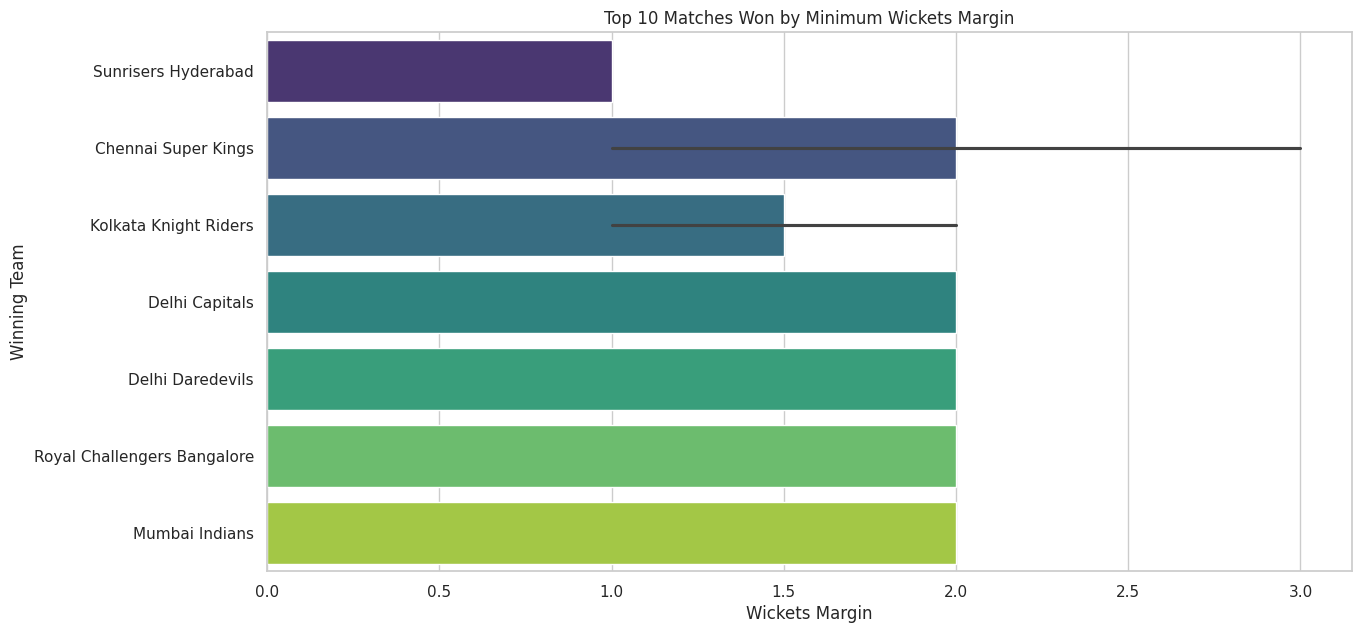

In [ ]:
#Jagriti Tiwari
# Filter for matches won by wickets (greater than 0)

matches_by_wickets = matches[matches['win_by_wickets'] > 0]

# Sort by win_by_wickets in ascending order and get the top 10 (smallest margins)
top_10_min_wicket_wins = matches_by_wickets.sort_values(by='win_by_wickets', ascending=True).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x='win_by_wickets', y='winner', data=top_10_min_wicket_wins, hue='winner', palette='viridis', legend=False)
plt.title('Top 10 Matches Won by Minimum Wickets Margin')
plt.xlabel('Wickets Margin')
plt.ylabel('Winning Team')
plt.show()

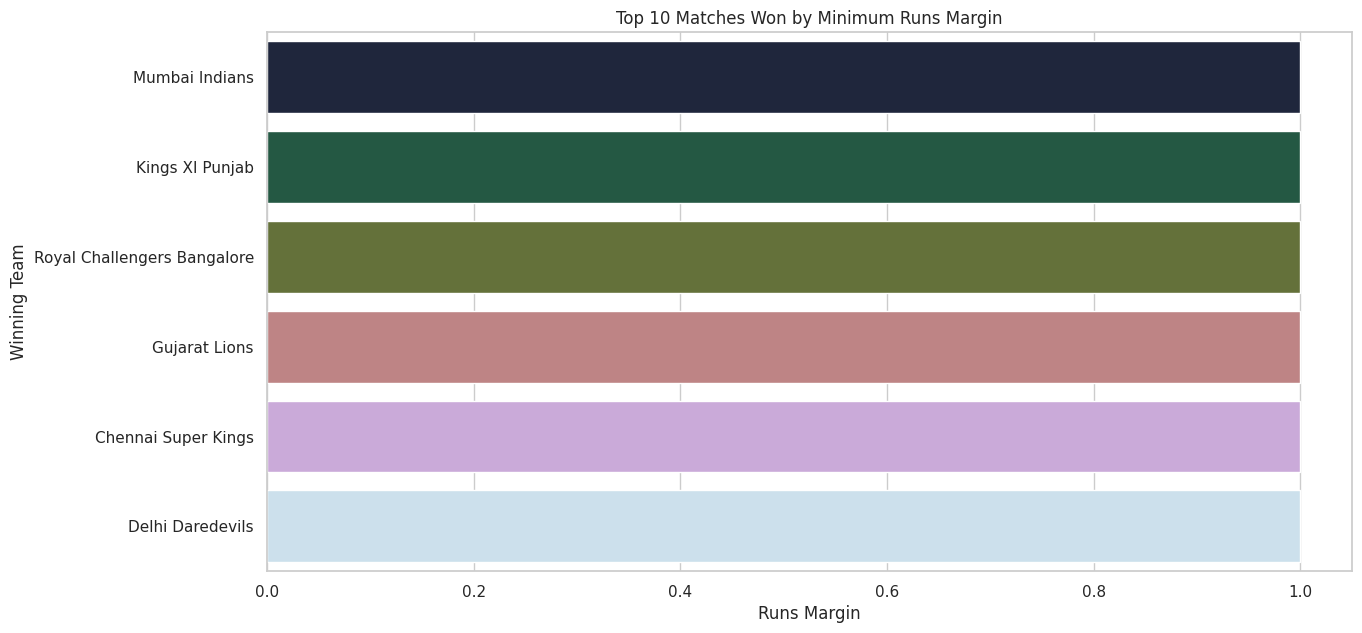

In [ ]:
#Jagriti Tiwari
# Filter for matches won by runs (greater than 0)

matches_by_runs_min = matches[matches['win_by_runs'] > 0]

# Sort by win_by_runs in ascending order and get the top 10 (smallest margins)
top_10_min_run_wins = matches_by_runs_min.sort_values(by='win_by_runs', ascending=True).head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x='win_by_runs', y='winner', data=top_10_min_run_wins, hue='winner', palette='cubehelix', legend=False)
plt.title('Top 10 Matches Won by Minimum Runs Margin')
plt.xlabel('Runs Margin')
plt.ylabel('Winning Team')
plt.show()

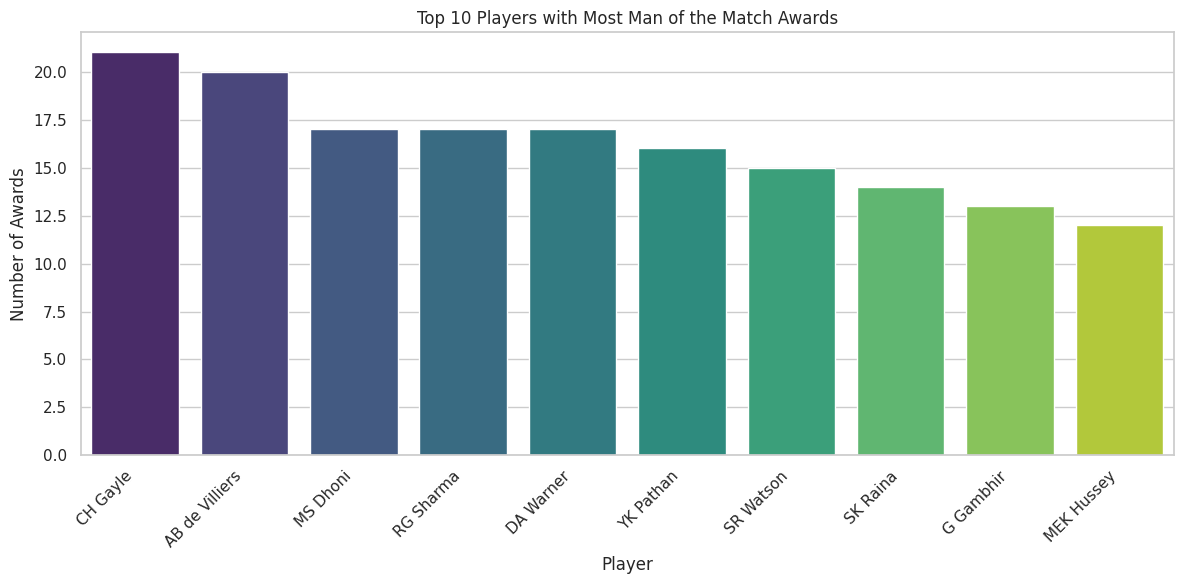

Top 10 players with most Man of the Match Awards:
player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
RG Sharma         17
DA Warner         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64

INSIGHT:
AB de Villiers and chris Gayle top the list,
showing the impact of explosive batsmen in IPL history.


In [ ]:
#Jagriti Tiwari
# Get the top 10 players with most 'player of the match' awards

top_10_players_of_match = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_players_of_match.index, y=top_10_players_of_match.values, hue=top_10_players_of_match.index, palette='viridis', legend=False)
plt.title('Top 10 Players with Most Man of the Match Awards')
plt.xlabel('Player')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 players with most Man of the Match Awards:")
print(top_10_players_of_match)

print("\nINSIGHT:")
print("AB de Villiers and chris Gayle top the list,")
print("showing the impact of explosive batsmen in IPL history.")


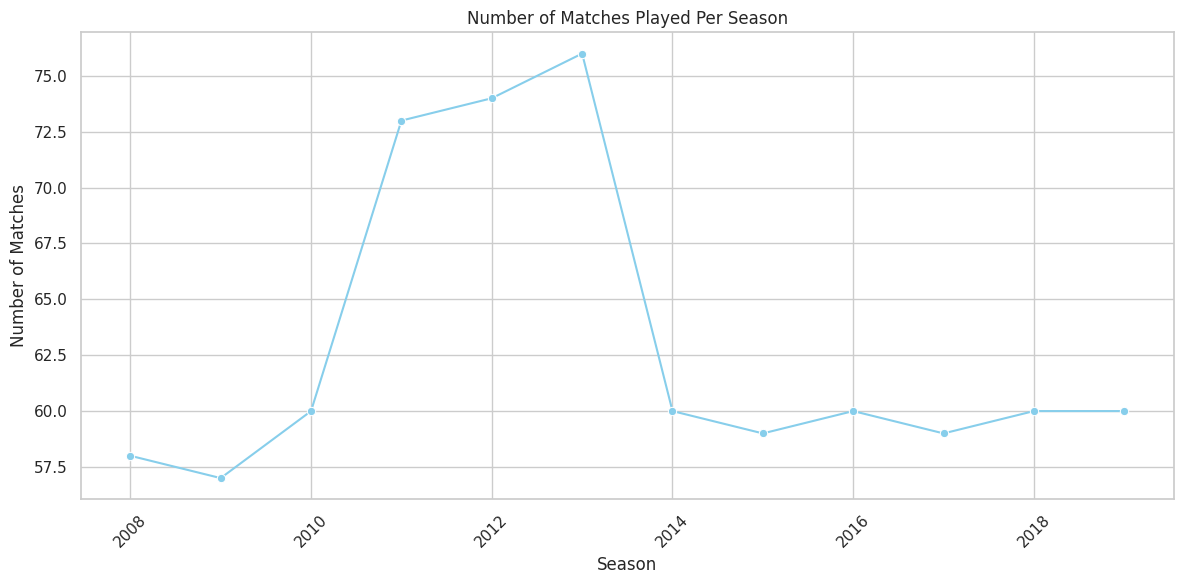

Matches per season:
season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64

INSIGHT:
matches increased from 60 to 74 after more teams joined IPL
2013season had maximum matches (76) so far


In [ ]:
#Jagriti Tiwari
# Calculate the number of matches per season

matches_per_season = matches['season'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=matches_per_season.index, y=matches_per_season.values, marker='o', color='skyblue')
plt.title('Number of Matches Played Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Matches per season:")
print(matches_per_season)

print("\nINSIGHT:")
print("matches increased from 60 to 74 after more teams joined IPL")
print("2013season had maximum matches (76) so far")

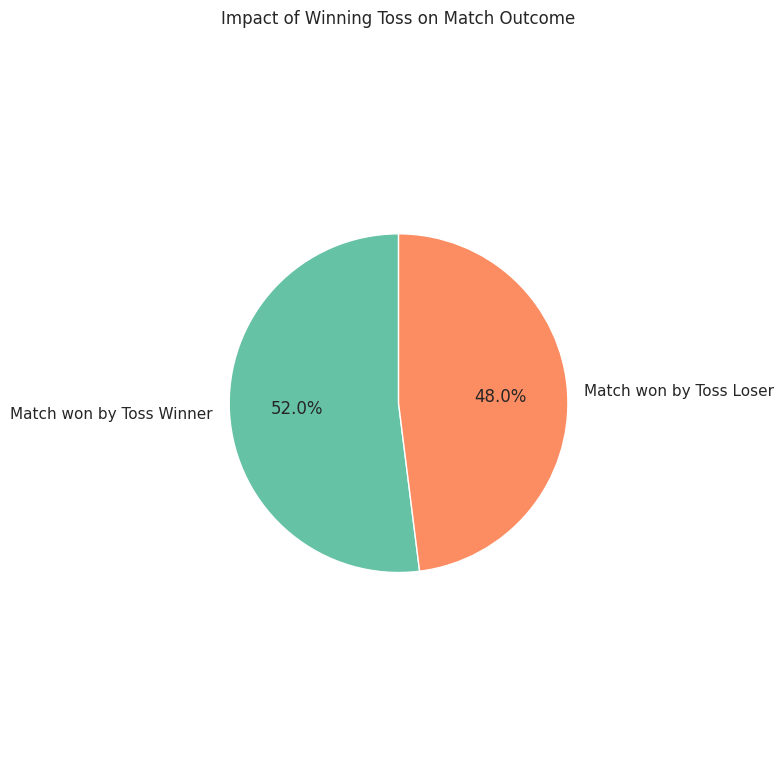


INSIGHT:
Only -52% matches won by toss winners - almost 50-50
Toss os NOT a big advantage in IPL, skill matters more.


In [ ]:
#Jagriti Tiwari
# Calculate the number of matches won by the toss winning team

toss_and_match_winners = matches[matches['toss_winner'] == matches['winner']]
wins_by_toss_winners = len(toss_and_match_winners)

# Calculate the number of matches won by the toss losing team
wins_by_toss_losers = len(matches) - wins_by_toss_winners

# Create a Series for the pie chart
toss_win_impact = pd.Series({
    'Match won by Toss Winner': wins_by_toss_winners,
    'Match won by Toss Loser': wins_by_toss_losers
})

plt.figure(figsize=(8, 8))
plt.pie(toss_win_impact.values, labels=toss_win_impact.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title('Impact of Winning Toss on Match Outcome')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("Only -52% matches won by toss winners - almost 50-50")
print("Toss os NOT a big advantage in IPL, skill matters more.")

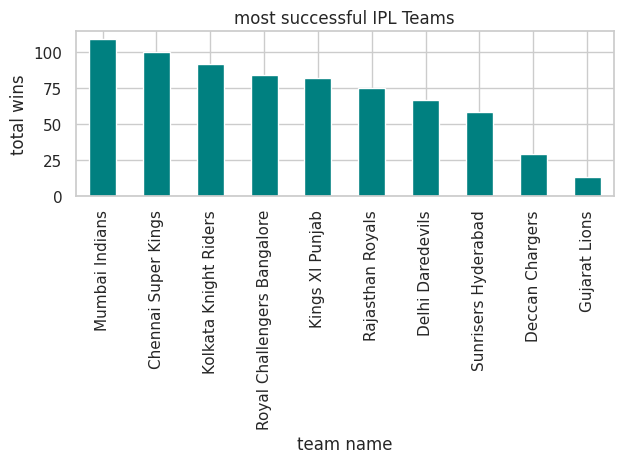

total wins by team:
winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Name: count, dtype: int64

INSIGHT:
Mumbai Indians and CSK dominate the wins tally, 
showing thier consistency and storing team performance over the year


In [ ]:
#Jagriti Tiwari
#team wins analysis

team_wins = matches['winner'].value_counts().head(10)
team_wins.plot(kind='bar', color='teal') #color change
plt.title('most successful IPL Teams')
plt.xlabel('team name')
plt.ylabel('total wins')
plt.tight_layout()
plt.show()

print("total wins by team:")
print(team_wins)

print("\nINSIGHT:")
print("Mumbai Indians and CSK dominate the wins tally, ")
print("showing thier consistency and storing team performance over the year")

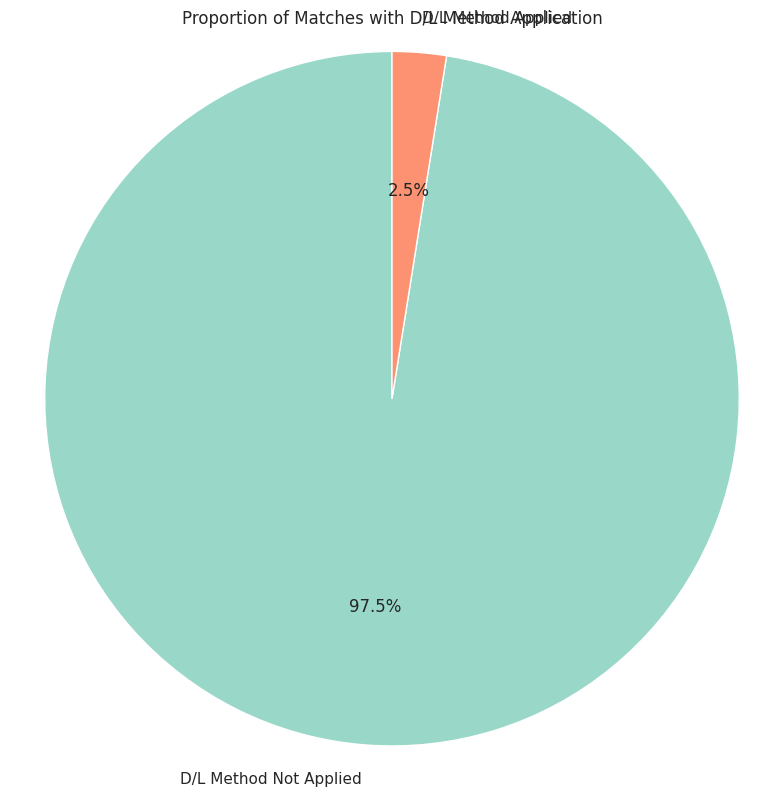


INSIGHT:
only about 2-3% of IPL matches required D/L method
mostly in rain-affected cities like Bengaluru and Kolkata


In [ ]:
#Jagriti tiwari
#D/L method analysis

# Count matches where D/L method was applied and wasn't
dl_applied_counts = matches['dl_applied'].value_counts()

# Map 0 and 1 to more descriptive labels
dl_labels = ['D/L Method Not Applied', 'D/L Method Applied']
dl_sizes = [dl_applied_counts.get(0, 0), dl_applied_counts.get(1, 0)]

plt.figure(figsize=(8, 8))
plt.pie(dl_sizes, labels=dl_labels, autopct='%1.1f%%', startangle=90, colors=['#99d8c9', '#fc9272'])
plt.title('Proportion of Matches with D/L Method Application')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("only about 2-3% of IPL matches required D/L method")
print("mostly in rain-affected cities like Bengaluru and Kolkata")

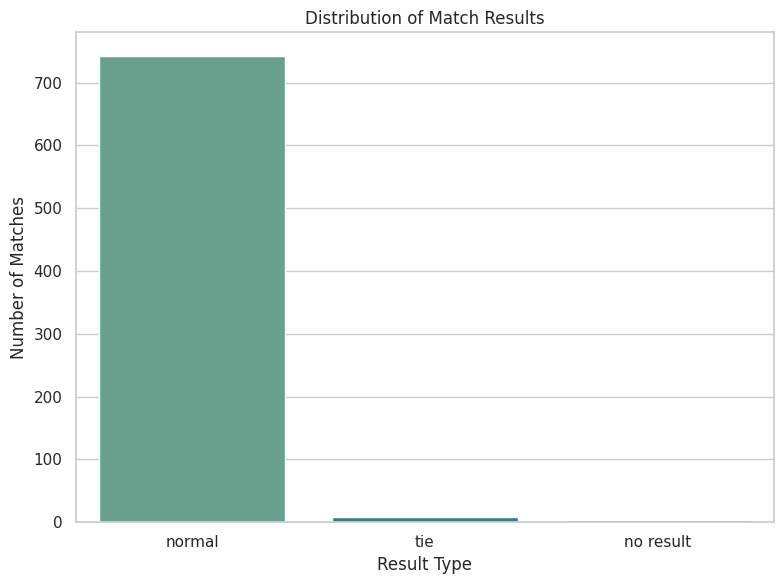

Result types:
result
normal       743
tie            9
no result      4
Name: count, dtype: int64

INSIGHT:
Majority matches have clear results(normal wins).
Very few ties or no results, amkig IPL exciting and decisive.


In [ ]:
#Jagriti Tiwari
# Calculate the counts of different match results

match_results = matches['result'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=match_results.index, y=match_results.values, hue=match_results.index, palette='crest', legend=False)
plt.title('Distribution of Match Results')
plt.xlabel('Result Type')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Result types:")
print(match_results)

print("\nINSIGHT:")
print("Majority matches have clear results(normal wins).")
print("Very few ties or no results, amkig IPL exciting and decisive.")

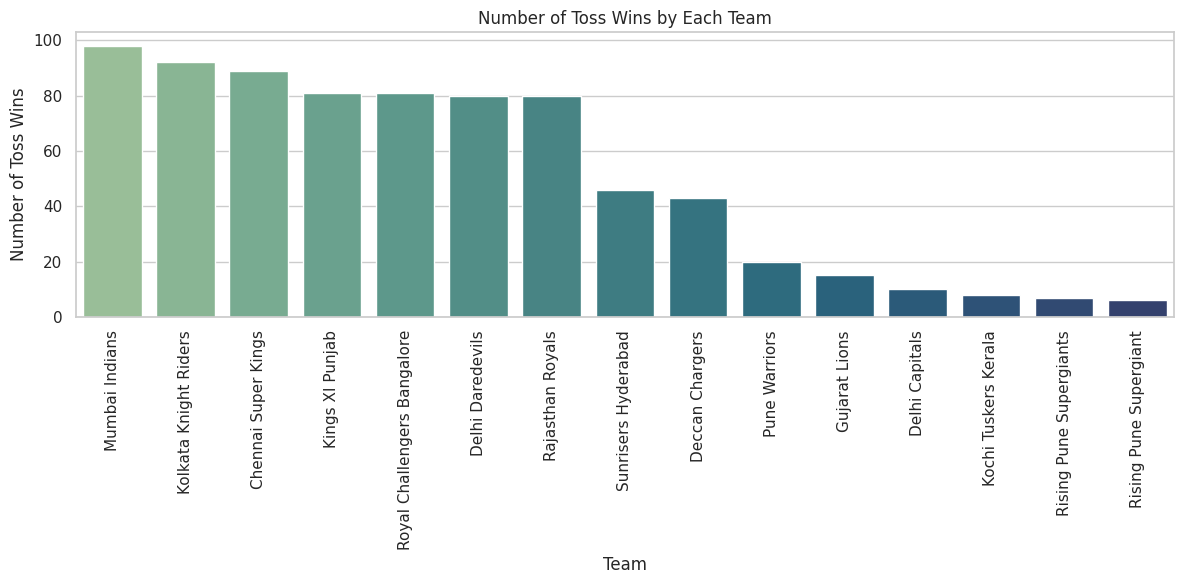

Number of toss wins by each team:
toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Kings XI Punjab                81
Royal Challengers Bangalore    81
Delhi Daredevils               80
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

INSIGHT:
Mumbai INdians andCSK also top toss charts.
either licky teams or they play more matches consistently.


In [ ]:
#Jagriti Tiwari
# Count how many times each team won the toss

toss_wins_by_team = matches['toss_winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=toss_wins_by_team.index, y=toss_wins_by_team.values, hue=toss_wins_by_team.index, palette='crest', legend=False)
plt.title('Number of Toss Wins by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Toss Wins')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Number of toss wins by each team:")
print(toss_wins_by_team)

print("\nINSIGHT:")
print("Mumbai INdians andCSK also top toss charts.")
print("either licky teams or they play more matches consistently.")

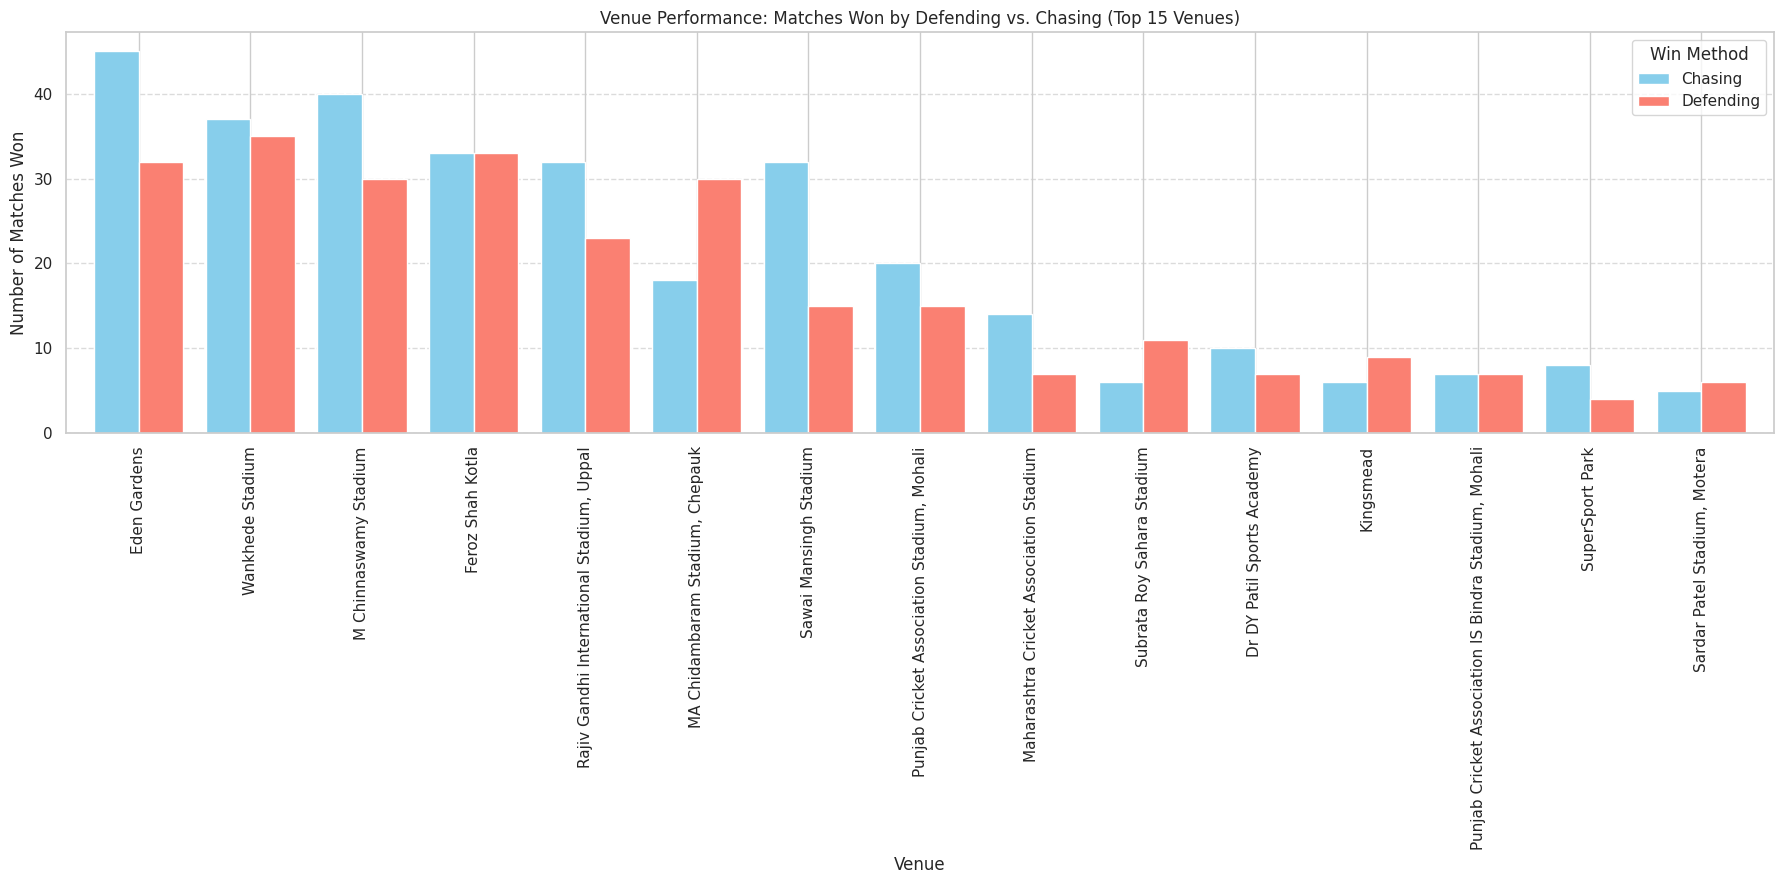


INSIGHT:
Eden Gardens and Wankhede favor chasing due to dew.
Chinnaswamy favors defending due to high scores on small ground.


In [ ]:
#Jagriti Tiwari
# Filter out matches that were ties or had no result, focusing on decisive wins

decisive_matches = matches[(matches['win_by_runs'] > 0) | (matches['win_by_wickets'] > 0)].copy()

# Create a 'win_method' column: 'Defending' if won by runs, 'Chasing' if won by wickets
decisive_matches['win_method'] = decisive_matches.apply(
    lambda row: 'Defending' if row['win_by_runs'] > 0 else 'Chasing',
    axis=1
)

# Group by venue and win_method to count matches
venue_performance = decisive_matches.groupby(['venue', 'win_method']).size().unstack(fill_value=0)

# Calculate total wins per venue to sort and select top venues
venue_performance['Total_Wins'] = venue_performance['Chasing'] + venue_performance['Defending']
venue_performance_sorted = venue_performance.sort_values(by='Total_Wins', ascending=False).drop(columns='Total_Wins')

# Select top 15 venues for clearer visualization
top_n_venues = venue_performance_sorted.head(15)

# Plotting the grouped bar chart
plt.figure(figsize=(18, 9))
top_n_venues.plot(kind='bar', figsize=(18, 9), width=0.8, color=['skyblue', 'salmon'], ax=plt.gca()) # Use ax=plt.gca() to plot on current figure
plt.title('Venue Performance: Matches Won by Defending vs. Chasing (Top 15 Venues)')
plt.xlabel('Venue')
plt.ylabel('Number of Matches Won')
plt.xticks(rotation=90)
plt.legend(title='Win Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nINSIGHT:")
print("Eden Gardens and Wankhede favor chasing due to dew.")
print("Chinnaswamy favors defending due to high scores on small ground.")

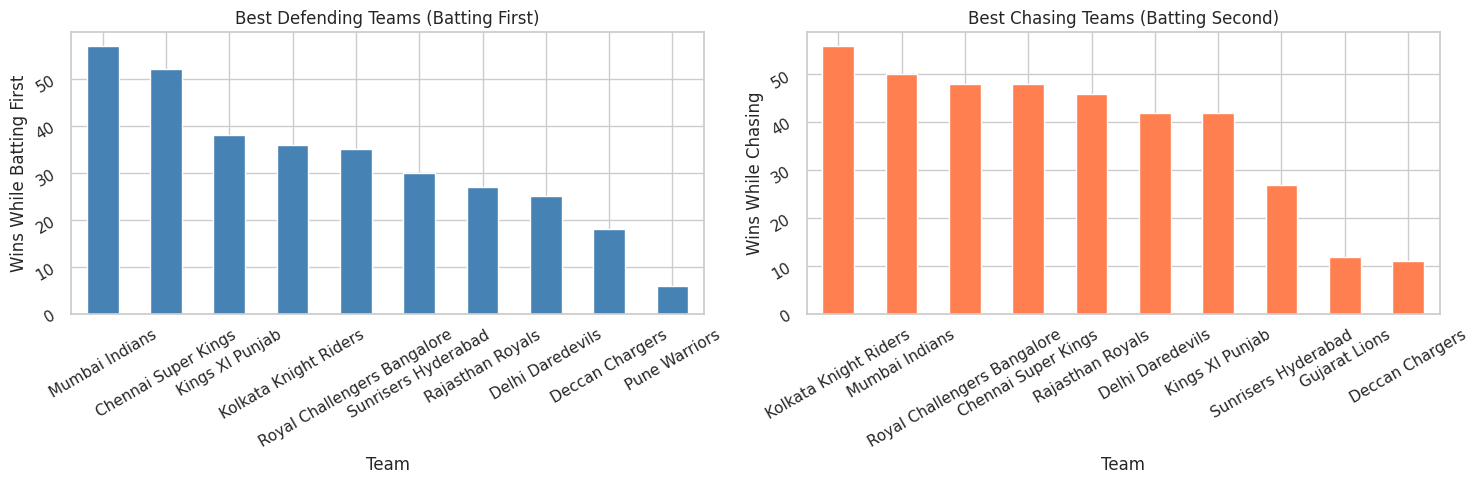

Best defenders (batting first):
winner
Mumbai Indians                 57
Chennai Super Kings            52
Kings XI Punjab                38
Kolkata Knight Riders          36
Royal Challengers Bangalore    35
Sunrisers Hyderabad            30
Rajasthan Royals               27
Delhi Daredevils               25
Deccan Chargers                18
Pune Warriors                   6
Name: count, dtype: int64

Best chasers (batting second):
winner
Kolkata Knight Riders          56
Mumbai Indians                 50
Royal Challengers Bangalore    48
Chennai Super Kings            48
Rajasthan Royals               46
Delhi Daredevils               42
Kings XI Punjab                42
Sunrisers Hyderabad            27
Gujarat Lions                  12
Deccan Chargers                11
Name: count, dtype: int64

INSIGHT:
MI and CSK excel at both defending and chasing.
KKR specializes in chasing, especially at Eden Gardens.


In [ ]:
#Jagriti Tiwari
#best teams analysis

defend_teams = matches[matches['win_by_runs'] > 0]['winner'].value_counts().head(10)
chase_teams = matches[matches['win_by_wickets'] > 0]['winner'].value_counts().head(10)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
defend_teams.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Best Defending Teams (Batting First)')
ax1.set_xlabel('Team')
ax1.set_ylabel('Wins While Batting First')
ax1.tick_params(rotation=30)
chase_teams.plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('Best Chasing Teams (Batting Second)')
ax2.set_xlabel('Team')
ax2.set_ylabel('Wins While Chasing')
ax2.tick_params(rotation=30)
plt.tight_layout()
plt.show()

print("Best defenders (batting first):")
print(defend_teams)
print("\nBest chasers (batting second):")
print(chase_teams)

print("\nINSIGHT:")
print("MI and CSK excel at both defending and chasing.")
print("KKR specializes in chasing, especially at Eden Gardens.")

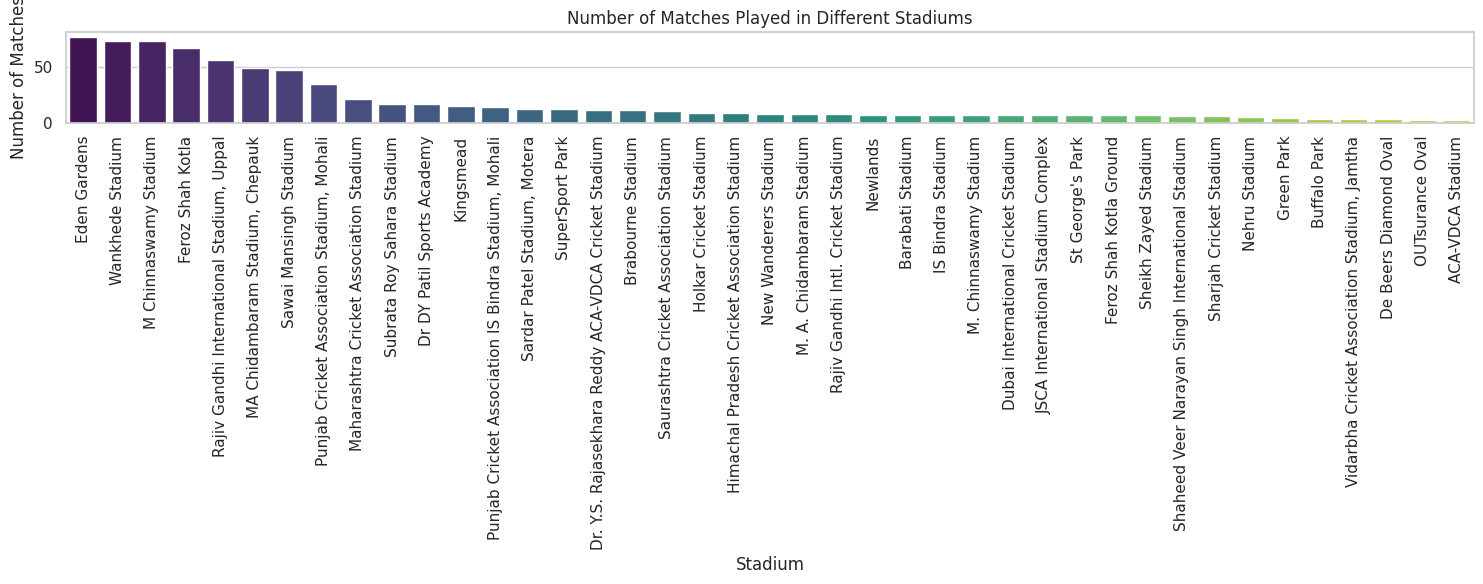

In [ ]:
#jagriti Tiwari
# Calculate the number of matches played in each venue

matches_per_venue = matches['venue'].value_counts()

plt.figure(figsize=(15, 6))
sns.barplot(x=matches_per_venue.index, y=matches_per_venue.values, hue=matches_per_venue.index, palette='viridis', legend=False)
plt.title('Number of Matches Played in Different Stadiums')
plt.xlabel('Stadium')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

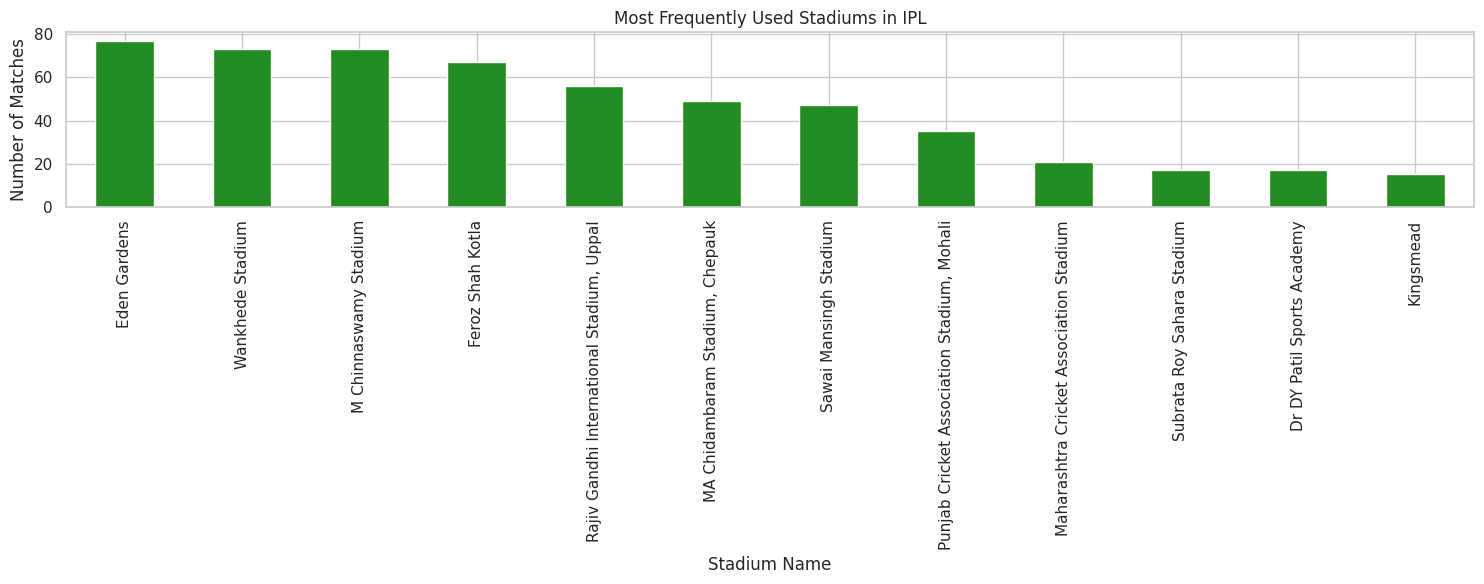

Top stadiums:
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         73
Feroz Shah Kotla                              67
Rajiv Gandhi International Stadium, Uppal     56
MA Chidambaram Stadium, Chepauk               49
Sawai Mansingh Stadium                        47
Punjab Cricket Association Stadium, Mohali    35
Maharashtra Cricket Association Stadium       21
Subrata Roy Sahara Stadium                    17
Dr DY Patil Sports Academy                    17
Kingsmead                                     15
Name: count, dtype: int64

INSIGHT:
Eden Gardens, Wankhede, and Chinnaswamy host most matches.
These are traditional cricket hubs with passionate fans.


In [ ]:
#Jagriti Tiwari
#stadium analysis
stadium_counts = matches['venue'].value_counts().head(12)
plt.figure(figsize=(15,6))
stadium_counts.plot(kind='bar', color='forestgreen')
plt.title('Most Frequently Used Stadiums in IPL')
plt.xlabel('Stadium Name')
plt.ylabel('Number of Matches')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top stadiums:")
print(stadium_counts)

print("\nINSIGHT:")
print("Eden Gardens, Wankhede, and Chinnaswamy host most matches.")
print("These are traditional cricket hubs with passionate fans.")